# EUR/USD Mean Reversion Strategy
### Spot FX vs 6E Futures Backtest

This notebook compares a simple Bollinger Band + slope mean reversion strategy on:
- EUR/USD spot FX (IBKR)
- 6E CME Futures

In [5]:
import pandas as pd

df_spot = pd.read_csv("data/EURUSD_IBKR.csv", parse_dates=["date"])
df_spot.set_index("date", inplace=True)
df_spot.head()


,open,high,low,close,volume,average,barCount
date,,,,,,,
2005-05-30,1.2536,1.25460,1.2466,1.24760,-1.0,-1.0,-1
2005-05-31,1.2476,1.24870,1.2296,1.23030,-1.0,-1.0,-1
2005-06-01,1.2308,1.23410,1.2159,1.21790,-1.0,-1.0,-1
2005-06-02,1.2205,1.22975,1.2182,1.22660,-1.0,-1.0,-1
2005-06-03,1.2275,1.23430,1.2205,1.22345,-1.0,-1.0,-1


In [7]:
from strategies.mean_reversion import apply_mean_reversion_strategy

df_spot = apply_mean_reversion_strategy(df_spot, window=8, slope_window=3)


In [9]:
from utils.backtest_engine import simulate_trades

df_spot = simulate_trades(df_spot)


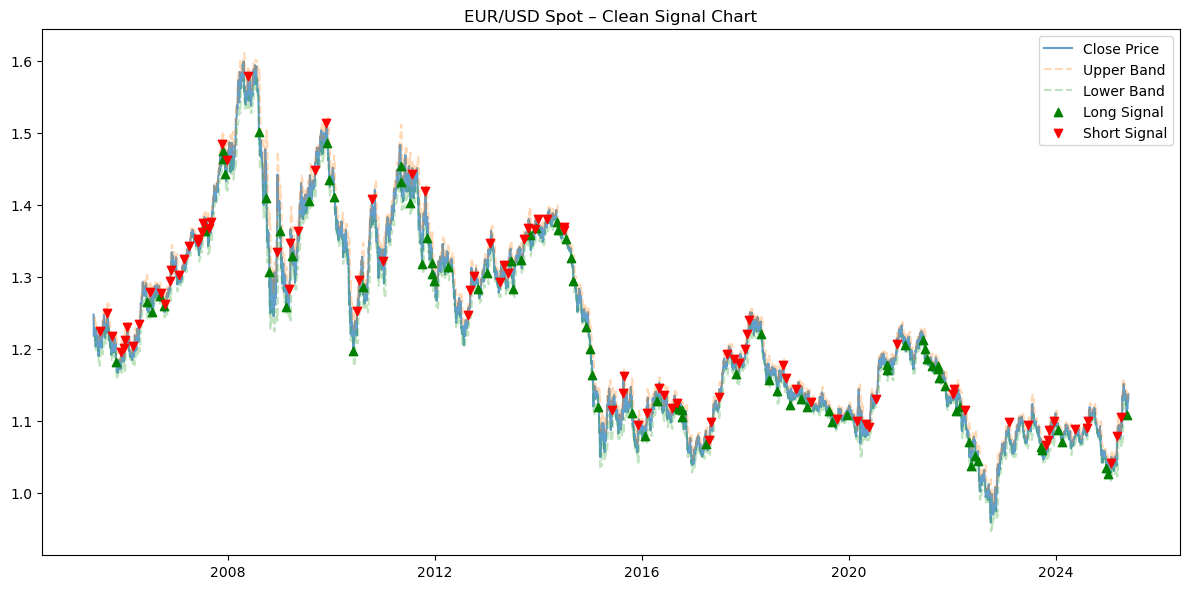

In [11]:
import matplotlib.pyplot as plt

def plot_signals(df, title):
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['close'], label='Close Price', alpha=0.7)
    plt.plot(df.index, df['upper'], linestyle='--', alpha=0.3, label='Upper Band')
    plt.plot(df.index, df['lower'], linestyle='--', alpha=0.3, label='Lower Band')
    plt.scatter(df[df['signal'] == 1].index, df[df['signal'] == 1]['close'],
                marker='^', color='green', label='Long Signal', zorder=3)
    plt.scatter(df[df['signal'] == -1].index, df[df['signal'] == -1]['close'],
                marker='v', color='red', label='Short Signal', zorder=3)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_signals(df_spot, "EUR/USD Spot – Clean Signal Chart")


In [17]:
# Display performance metrics (SPOT)
long_signals = df_spot[df_spot['signal'] == 1].shape[0]
short_signals = df_spot[df_spot['signal'] == -1].shape[0]

total_return = df_spot['equity'].iloc[-1] - 100
cagr = (df_spot['equity'].iloc[-1] / 100) ** (1 / (len(df_spot) / 252)) - 1
sharpe = df_spot['strategy_returns'].mean() / df_spot['strategy_returns'].std() * (252**0.5)
max_dd = (df_spot['equity'].cummax() - df_spot['equity']).max()

print(f"📉 EUR/USD Spot Strategy Performance:")
print(f"• Long signals: {long_signals}")
print(f"• Short signals: {short_signals}")
print(f"• Total Return: {total_return:.2f}%")
print(f"• CAGR: {cagr:.2%}")
print(f"• Sharpe Ratio: {sharpe:.2f}")
print(f"• Max Drawdown: {max_dd:.2f}%")


📉 EUR/USD Spot Strategy Performance:
• Long signals: 89
• Short signals: 95
• Total Return: -8.72%
• CAGR: -0.44%
• Sharpe Ratio: -0.29
• Max Drawdown: 15.66%


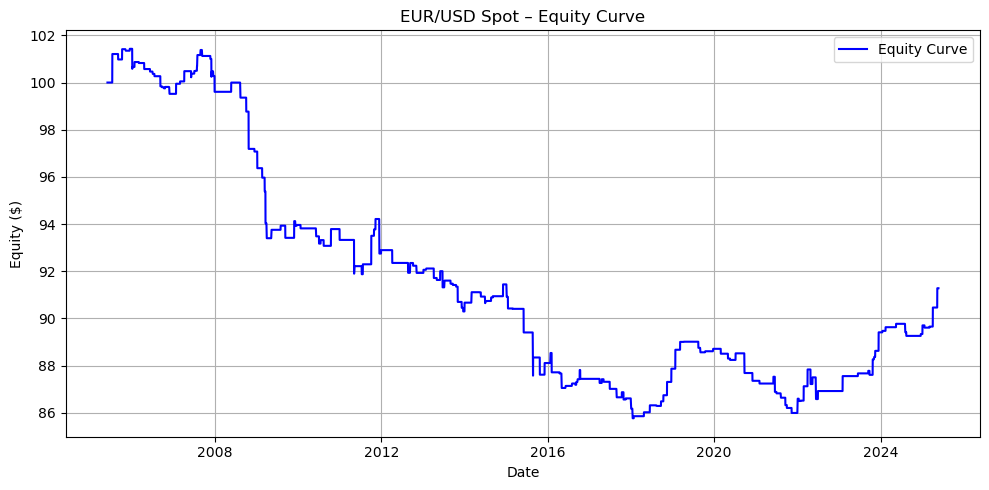

In [13]:
def plot_equity_curve(df, title):
    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df['equity'], label='Equity Curve', color='blue')
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity ($)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_equity_curve(df_spot, "EUR/USD Spot – Equity Curve")



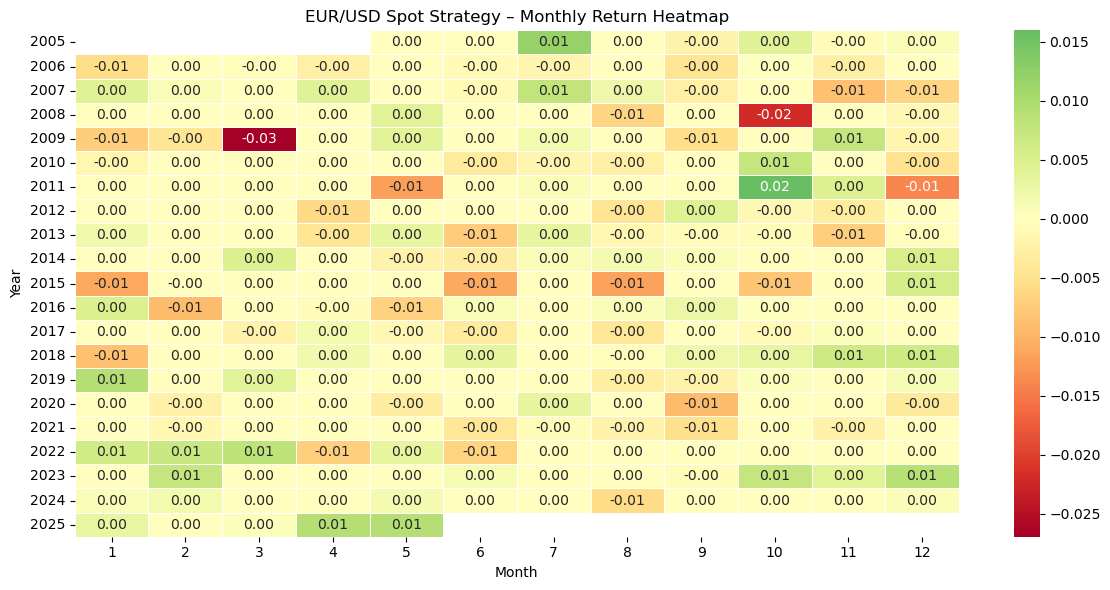

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare monthly return heatmap
df_spot['year'] = df_spot.index.year
df_spot['month'] = df_spot.index.month
df_spot['monthly_return'] = df_spot['strategy_returns']

# Group by year and month, sum monthly returns
monthly_heatmap = df_spot.groupby(['year', 'month'])['monthly_return'].sum().unstack()

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(monthly_heatmap, cmap="RdYlGn", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("EUR/USD Spot Strategy – Monthly Return Heatmap")
plt.ylabel("Year")
plt.xlabel("Month")
plt.tight_layout()
plt.show()


In [25]:
# 1. Load 6E Futures Data
df_6e = pd.read_csv("data/6E_proxy.csv", parse_dates=["date"])
df_6e.set_index("date", inplace=True)

# 2. Apply Strategy
df_6e = apply_mean_reversion_strategy(df_6e, window=8, slope_window=3)

# 3. Simulate Trades
df_6e = simulate_trades(df_6e)

# 4. Plot Signal Chart
plot_signals(df_6e, "6E Futures – Clean Signal Chart")

# 5. Show Performance
long_signals = df_6e[df_6e['signal'] == 1].shape[0]
short_signals = df_6e[df_6e['signal'] == -1].shape[0]

total_return = df_6e['equity'].iloc[-1] - 100
cagr = (df_6e['equity'].iloc[-1] / 100) ** (1 / (len(df_6e) / 252)) - 1
sharpe = df_6e['strategy_returns'].mean() / df_6e['strategy_returns'].std() * (252**0.5)
max_dd = (df_6e['equity'].cummax() - df_6e['equity']).max()

print(f"📉 6E Futures Strategy Performance:")
print(f"• Long signals: {long_signals}")
print(f"• Short signals: {short_signals}")
print(f"• Total Return: {total_return:.2f}%")
print(f"• CAGR: {cagr:.2%}")
print(f"• Sharpe Ratio: {sharpe:.2f}")
print(f"• Max Drawdown: {max_dd:.2f}%")

# 6. Plot Equity Curve
plot_equity_curve(df_6e, "6E Futures – Equity Curve")


FileNotFoundError: [Errno 2] No such file or directory: 'data/6E_proxy.csv'

In [2]:
# === Load 6E Futures Proxy Data ===
import pandas as pd

df_6e = pd.read_csv("data/6E_continuous_proxy.csv", parse_dates=["date"])
df_6e.set_index("date", inplace=True)

print("✅ Loaded 6E data:")
print(df_6e.head())


✅ Loaded 6E data:
                open      high       low     close  volume
date                                                      
2004-01-01  1.200480  1.198960  1.200214  1.200993    2078
2004-01-02  1.199518  1.201018  1.199620  1.200717    4566
2004-01-05  1.203797  1.206245  1.203821  1.202012    4803
2004-01-06  1.205072  1.204740  1.205226  1.205058    4687
2004-01-07  1.204365  1.204953  1.203489  1.204590    4938


In [4]:
from strategies.mean_reversion import apply_mean_reversion_strategy
from utils.backtest_engine import simulate_trades

df_6e = apply_mean_reversion_strategy(df_6e, window=8, slope_window=3)
df_6e = simulate_trades(df_6e)


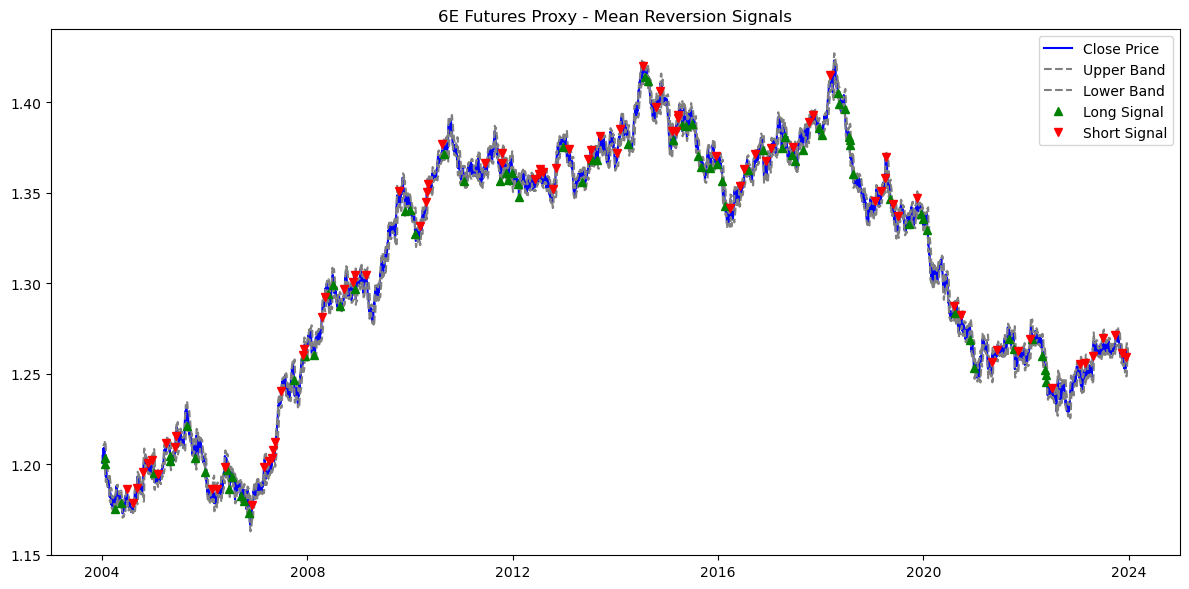

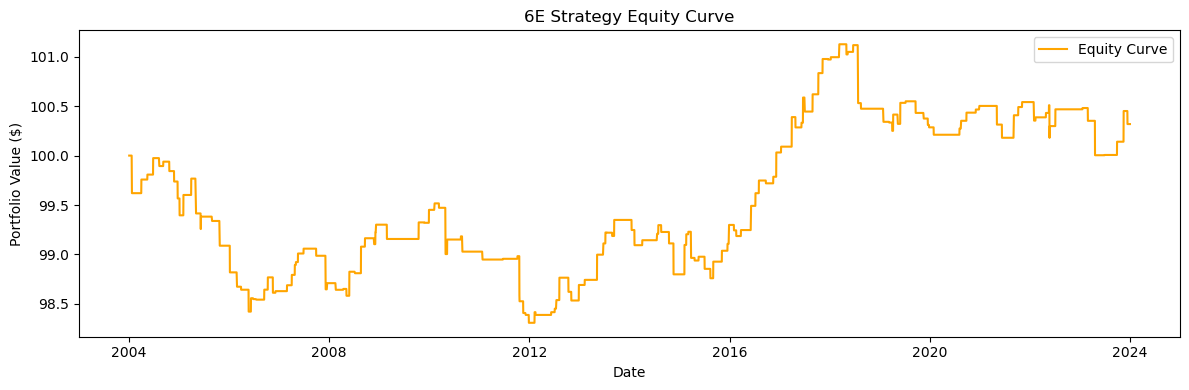

In [6]:
import matplotlib.pyplot as plt

# Plot signals
plt.figure(figsize=(12, 6))
plt.plot(df_6e["close"], label="Close Price", color="blue")
plt.plot(df_6e["upper"], "--", color="gray", label="Upper Band")
plt.plot(df_6e["lower"], "--", color="gray", label="Lower Band")
plt.plot(df_6e[df_6e["signal"] == 1].index, df_6e[df_6e["signal"] == 1]["close"], "^", color="green", label="Long Signal")
plt.plot(df_6e[df_6e["signal"] == -1].index, df_6e[df_6e["signal"] == -1]["close"], "v", color="red", label="Short Signal")
plt.title("6E Futures Proxy - Mean Reversion Signals")
plt.legend()
plt.tight_layout()
plt.show()

# Plot equity
plt.figure(figsize=(12, 4))
plt.plot(df_6e["equity"], color="orange", label="Equity Curve")
plt.title("6E Strategy Equity Curve")
plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
# === 6E Strategy Performance Metrics ===
try:
    total_return = df_6e['equity'].iloc[-1] / 100 - 1
    num_years = (df_6e.index[-1] - df_6e.index[0]).days / 365.25
    cagr = (df_6e['equity'].iloc[-1] / 100) ** (1 / num_years) - 1
    sharpe = df_6e['strategy_returns'].mean() / df_6e['strategy_returns'].std() * (252 ** 0.5)
    max_dd = ((df_6e['equity'].cummax() - df_6e['equity']) / df_6e['equity'].cummax()).max()

    print(f"\n📊 6E Strategy Performance:")
    print(f"• Total Return: {total_return:.2%}")
    print(f"• CAGR: {cagr:.2%}")
    print(f"• Sharpe Ratio: {sharpe:.2f}")
    print(f"• Max Drawdown: {max_dd:.2%}")
except Exception as e:
    print(f"\n⚠️ Failed to compute performance: {e}")



📊 6E Strategy Performance:
• Total Return: 0.32%
• CAGR: 0.02%
• Sharpe Ratio: 0.04
• Max Drawdown: 1.69%
